In [39]:
library(mgcv)
set.seed(123)

norm_data = read.csv("Data/Processed/nba_normal_scorers_filtered.csv")
# norm_data = norm_data[sample(nrow(norm_data), 900), ]

norm_data = subset(norm_data, select = -c(Player, Team, Pos, Awards, AllStarSelection, Rk))

norm_data = na.omit(norm_data)

n = floor(0.8 * nrow(norm_data))
index = sample(seq_len(nrow(norm_data)), size = n)

norm.train = norm_data[index, ]
norm.test = norm_data[-index, ]

head(norm.train)
summary(norm.train)

Loading required package: nlme

This is mgcv 1.9-3. For overview type 'help("mgcv-package")'.



,Age,G,GS,MP,FG,FGA,FG.,X3P,X3PA,X3P.,⋯,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Year,Salary
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>
511,32,55,7,17.3,2.2,5.2,0.433,0.7,1.5,0.439,⋯,1.3,1.6,2.4,0.6,0.2,1.2,1.0,6.7,2021,4110433
568,27,29,4,10.9,1.9,3.9,0.496,0.1,0.5,0.200,⋯,1.7,2.7,0.1,0.1,0.5,0.5,1.8,4.6,2021,2294633
209,24,37,12,24.5,1.8,4.4,0.414,0.6,1.9,0.324,⋯,1.8,2.3,2.1,1.1,0.1,0.8,1.6,4.6,2020,4906243
645,20,15,1,5.6,0.7,1.8,0.407,0.3,0.7,0.400,⋯,0.7,1.1,0.3,0.2,0.3,0.3,0.7,1.9,2021,1849950
229,25,42,5,13.5,1.3,3.2,0.406,0.9,2.6,0.351,⋯,1.7,2.6,0.4,0.1,0.5,0.2,1.1,3.7,2020,881609
1203,32,68,40,24.4,3.9,9.4,0.411,1.4,4.2,0.333,⋯,1.8,2.1,3.4,0.7,0.1,1.7,1.7,10.2,2023,12147949


      Age              G               GS              MP       
 Min.   :19.00   Min.   : 1.00   Min.   : 0.00   Min.   : 2.00  
 1st Qu.:22.00   1st Qu.:24.00   1st Qu.: 0.00   1st Qu.:12.03  
 Median :24.00   Median :48.00   Median : 5.00   Median :17.95  
 Mean   :25.46   Mean   :44.33   Mean   :18.51   Mean   :18.79  
 3rd Qu.:28.00   3rd Qu.:65.00   3rd Qu.:31.00   3rd Qu.:25.80  
 Max.   :43.00   Max.   :84.00   Max.   :83.00   Max.   :43.50  
       FG             FGA              FG.              X3P        
 Min.   :0.000   Min.   : 0.500   Min.   :0.0000   Min.   :0.0000  
 1st Qu.:1.400   1st Qu.: 3.400   1st Qu.:0.3990   1st Qu.:0.3000  
 Median :2.500   Median : 5.600   Median :0.4400   Median :0.7000  
 Mean   :2.947   Mean   : 6.499   Mean   :0.4456   Mean   :0.9073  
 3rd Qu.:4.000   3rd Qu.: 8.600   3rd Qu.:0.4920   3rd Qu.:1.3000  
 Max.   :8.800   Max.   :19.400   Max.   :0.7470   Max.   :4.0000  
      X3PA            X3P.             X2P             X2PA       
 M

Predicting Salary (Main Use Case)


Call:
lm(formula = Salary ~ Age + MP + FG + X3P + AST + DRB + STL + 
    BLK + Year, data = norm.train)

Residuals:
      Min        1Q    Median        3Q       Max 
-21060457  -3704280   -407480   3133318  31814264 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept) -139834138  271215476  -0.516  0.60624    
Age             730688      45114  16.196  < 2e-16 ***
MP             -181239      63827  -2.840  0.00460 ** 
FG             1713714     236581   7.244 7.94e-13 ***
X3P            1067096     403951   2.642  0.00836 ** 
AST            1471516     187001   7.869 8.15e-15 ***
DRB            1057180     231240   4.572 5.35e-06 ***
STL             185867     821627   0.226  0.82107    
BLK            1403452     642404   2.185  0.02911 *  
Year             59305     134101   0.442  0.65839    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 6441000 on 1160 degrees of freedom
Multiple R-squared:  0.5474,	Adju

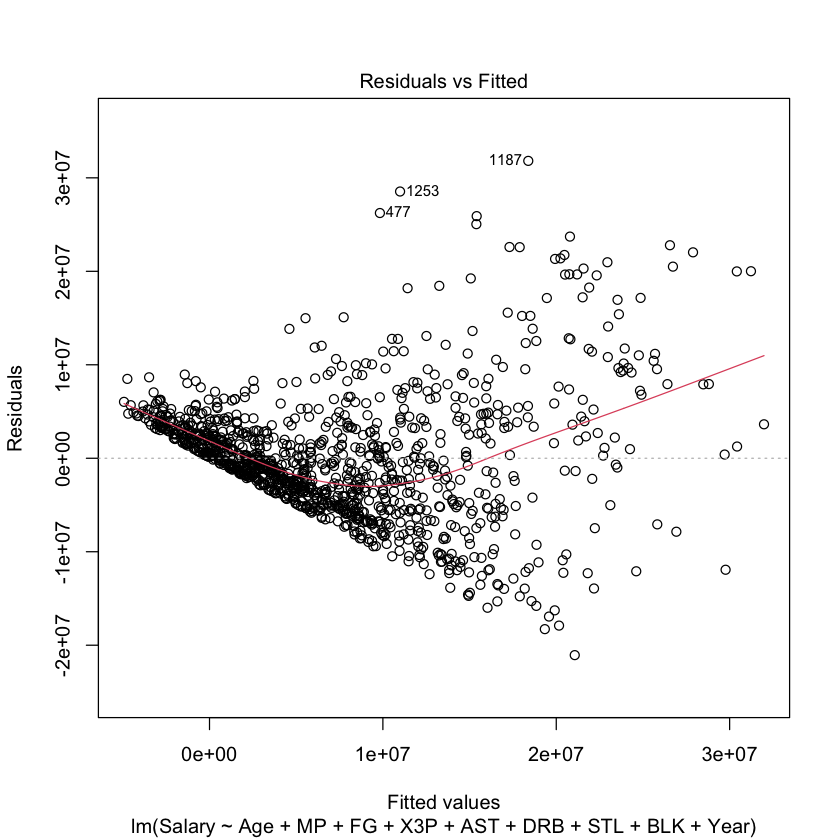

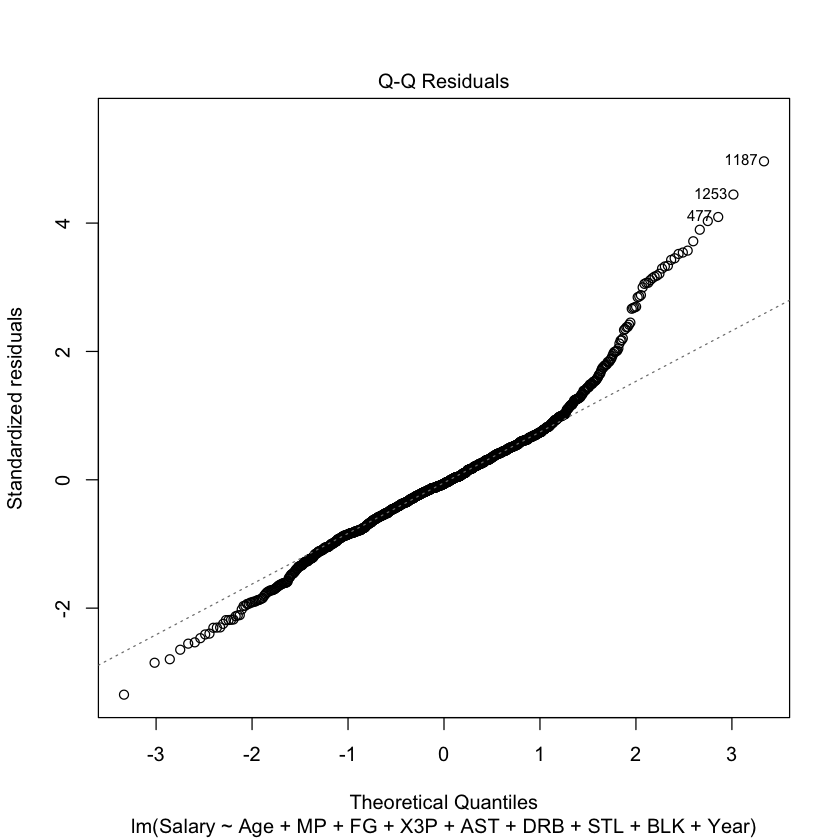

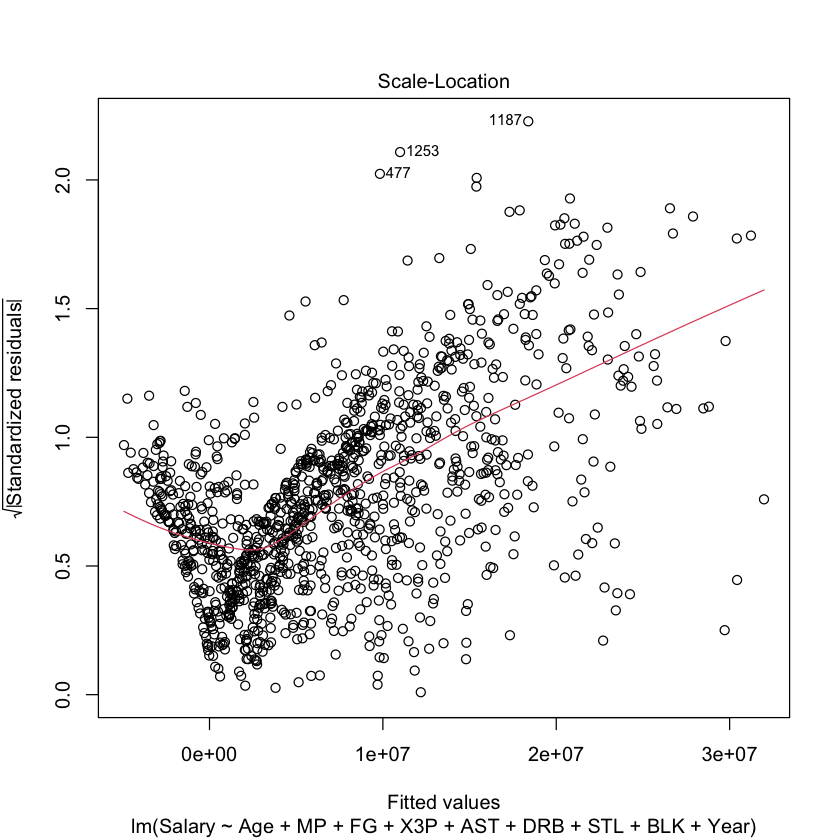

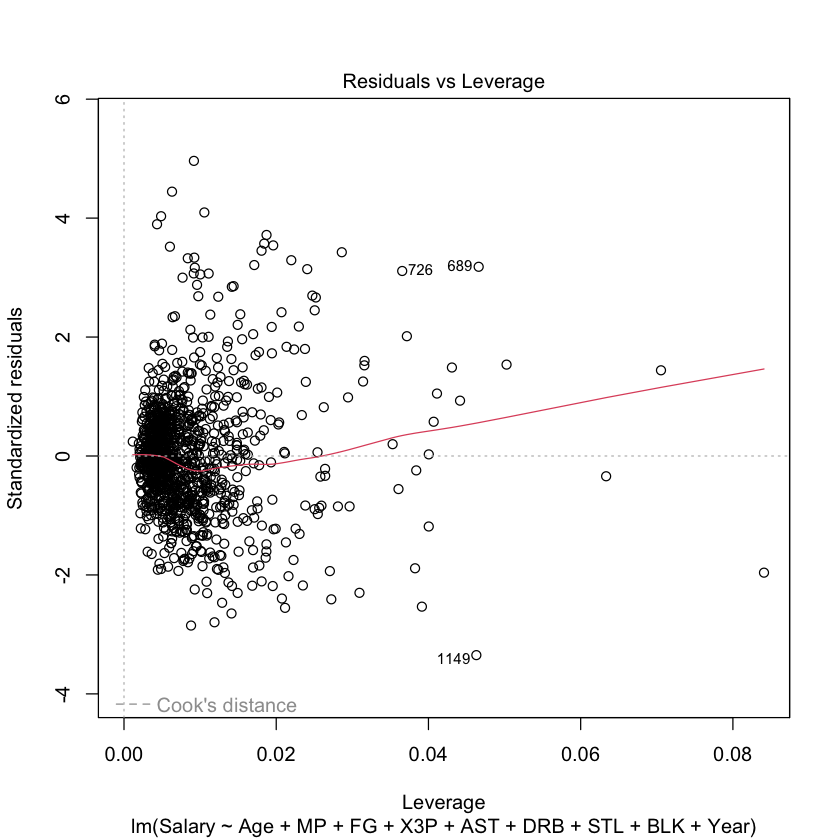

In [39]:
mod1 = lm(Salary ~ Age + MP + FG + X3P + AST + DRB + STL + BLK + Year, data = norm.train)
summary(mod1)
# par(mfrow = c(2, 2))
plot(mod1)

Start:  AIC=36696.82
Salary ~ Age + MP + FG + X3P + AST + DRB + STL + BLK + Year

       Df  Sum of Sq        RSS   AIC
- STL   1 2.1228e+12 4.8122e+16 36695
- Year  1 8.1131e+12 4.8128e+16 36695
<none>               4.8120e+16 36697
- BLK   1 1.9799e+14 4.8318e+16 36700
- X3P   1 2.8948e+14 4.8409e+16 36702
- MP    1 3.3447e+14 4.8454e+16 36703
- DRB   1 8.6703e+14 4.8987e+16 36716
- FG    1 2.1766e+15 5.0296e+16 36747
- AST   1 2.5686e+15 5.0688e+16 36756
- Age   1 1.0882e+16 5.9001e+16 36933

Step:  AIC=36694.87
Salary ~ Age + MP + FG + X3P + AST + DRB + BLK + Year

       Df  Sum of Sq        RSS   AIC
- Year  1 7.7923e+12 4.8129e+16 36693
<none>               4.8122e+16 36695
+ STL   1 2.1228e+12 4.8120e+16 36697
- BLK   1 2.0141e+14 4.8323e+16 36698
- X3P   1 2.8772e+14 4.8409e+16 36700
- MP    1 3.6003e+14 4.8482e+16 36702
- DRB   1 8.6496e+14 4.8987e+16 36714
- FG    1 2.1847e+15 5.0306e+16 36745
- AST   1 3.0802e+15 5.1202e+16 36765
- Age   1 1.0915e+16 5.9037e+16 36932

Step:


Call:
lm(formula = Salary ~ Age + MP + FG + X3P + AST + DRB + BLK, 
    data = norm.train)

Residuals:
      Min        1Q    Median        3Q       Max 
-21263264  -3681957   -370054   3084711  31841143 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) -19867815    1187890 -16.725  < 2e-16 ***
Age            729236      44936  16.228  < 2e-16 ***
MP            -176017      59761  -2.945  0.00329 ** 
FG            1708908     235228   7.265 6.83e-13 ***
X3P           1065720     403071   2.644  0.00830 ** 
AST           1489666     172469   8.637  < 2e-16 ***
DRB           1048380     230297   4.552 5.86e-06 ***
BLK           1422594     640213   2.222  0.02647 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 6436000 on 1162 degrees of freedom
Multiple R-squared:  0.5473,	Adjusted R-squared:  0.5446 
F-statistic: 200.7 on 7 and 1162 DF,  p-value: < 2.2e-16


,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1162,4.812947e+16,NA,NA,NA,NA
2,1160,4.811955e+16,2,9.915101e+12,0.1195098,0.8873662


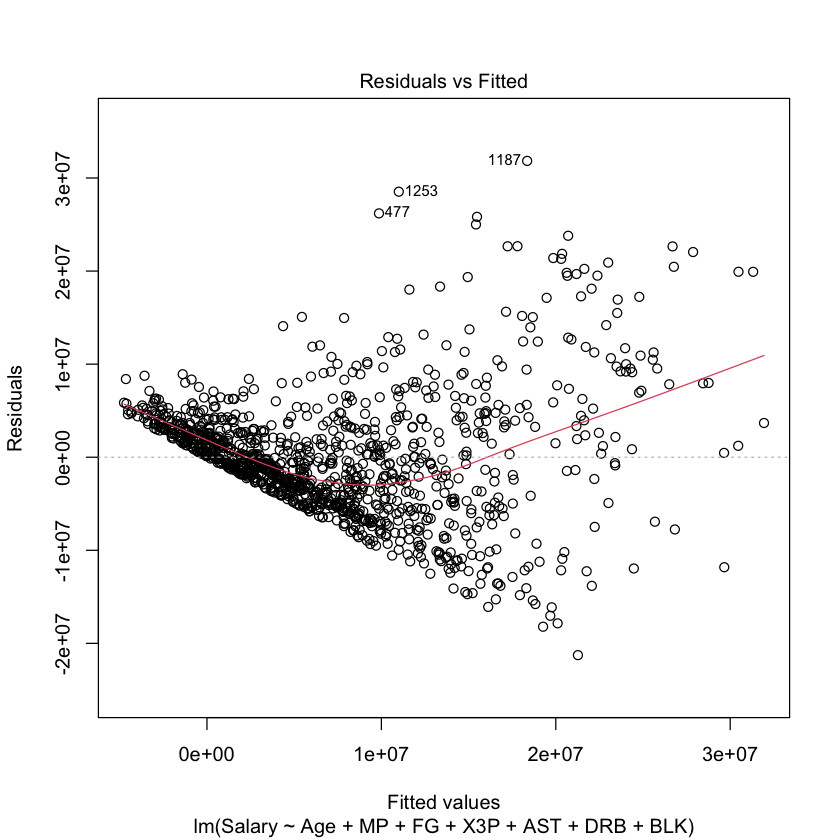

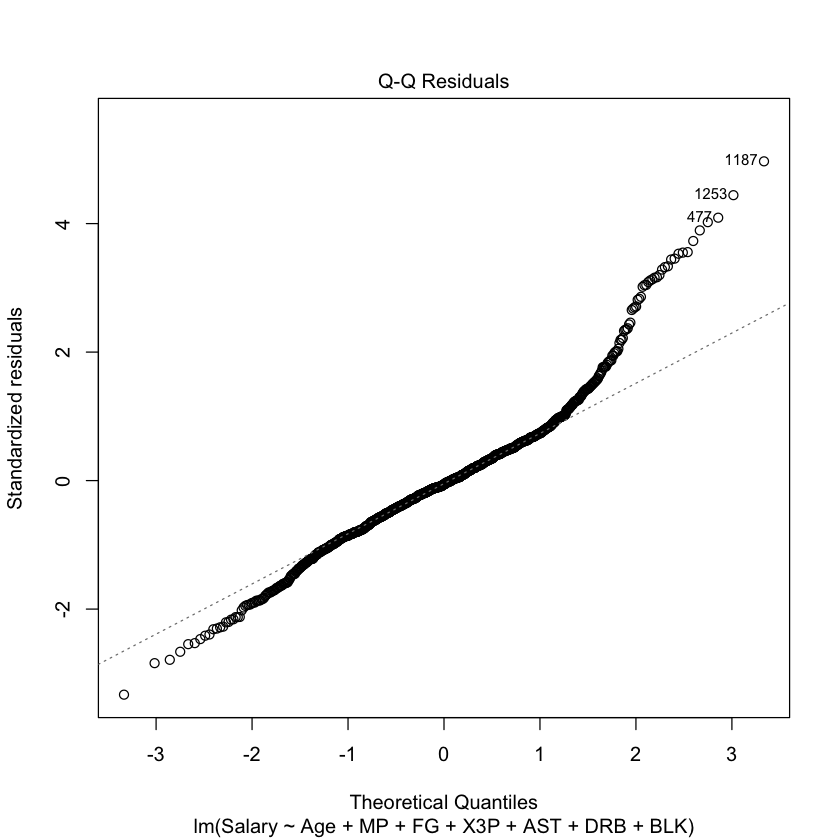

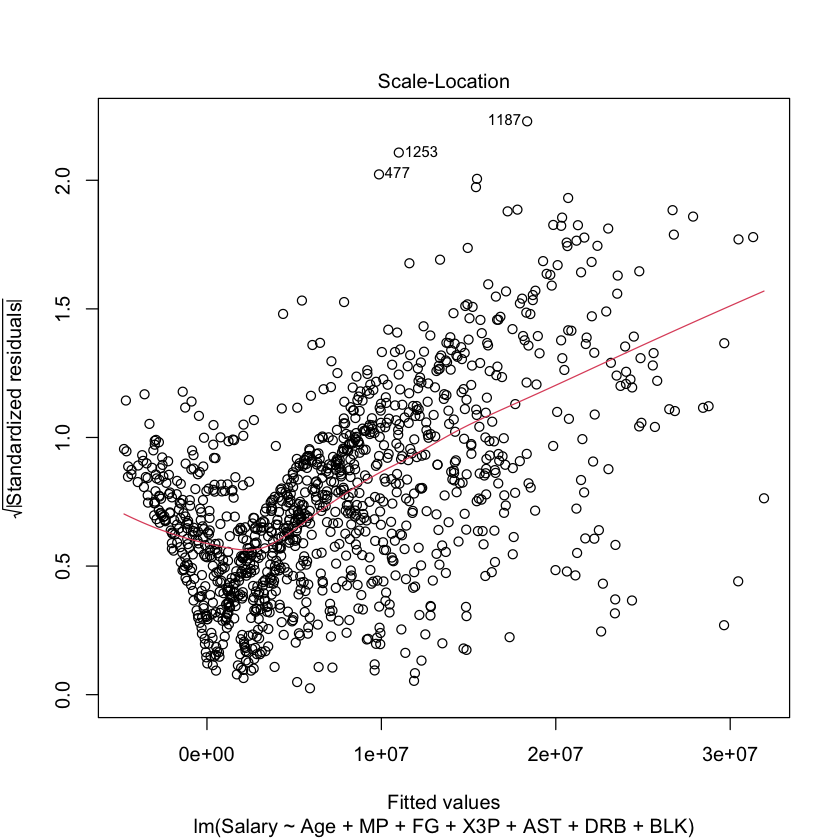

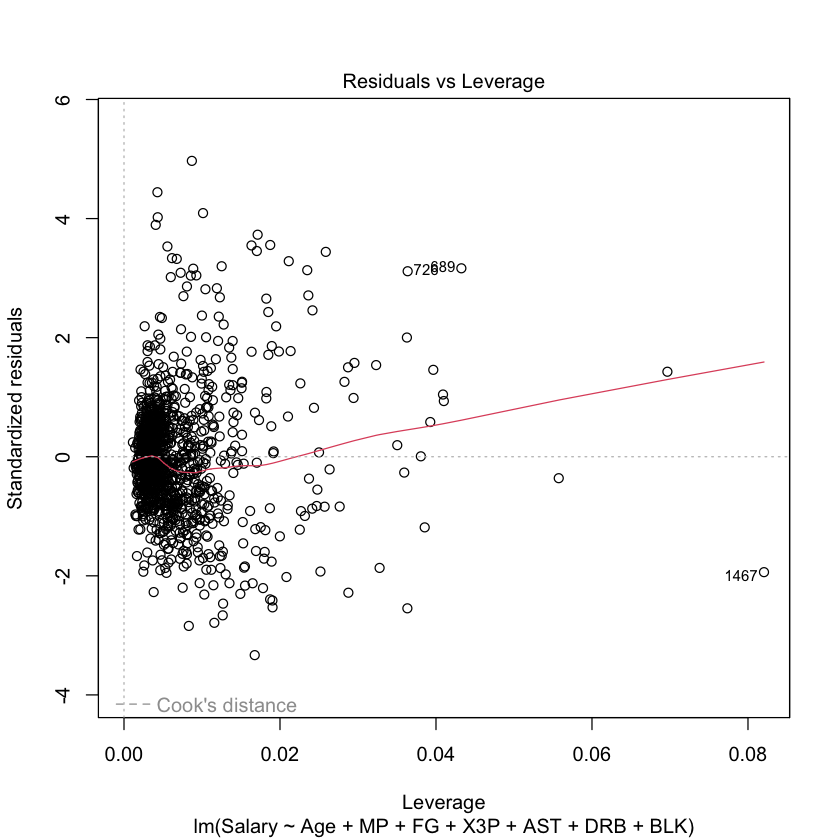

In [47]:
#Select best model using stepwise regression
library(MASS)
step_model <- step(mod1, direction = "both", trace = TRUE)

# View selected model summary
summary(step_model)

anova(step_model, mod1)

plot(step_model)

In [40]:
library(car)
vif_mod1 = vif(mod1)
print("VIF for mod1:")
print(vif_mod1)

[1] "VIF for mod1:"
     Age       MP       FG      X3P      AST      DRB      STL      BLK 
1.095336 8.797424 6.082974 2.707901 2.706014 4.008160 2.518169 1.898060 
    Year 
1.009424 


Predicting Points Scored (PTS)


Call:
lm(formula = PTS ~ log(FGA) + X3PA + FTA + TOV + AST, data = norm.train)

Residuals:
    Min      1Q  Median      3Q     Max 
-6.7797 -0.8869 -0.1500  0.6917  6.7057 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) -1.97266    0.11915 -16.556  < 2e-16 ***
log(FGA)     3.16047    0.12861  24.574  < 2e-16 ***
X3PA         0.57137    0.03294  17.347  < 2e-16 ***
FTA          1.70355    0.05346  31.866  < 2e-16 ***
TOV          0.41313    0.13181   3.134  0.00177 ** 
AST          0.10561    0.04346   2.430  0.01526 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1.433 on 1164 degrees of freedom
Multiple R-squared:  0.9272,	Adjusted R-squared:  0.9269 
F-statistic:  2967 on 5 and 1164 DF,  p-value: < 2.2e-16


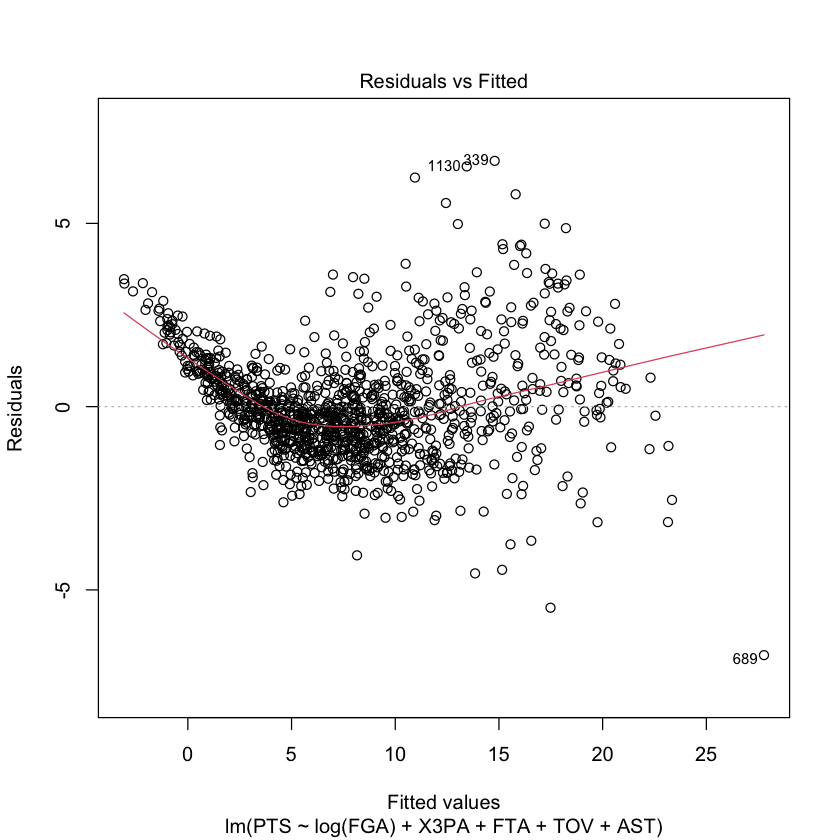

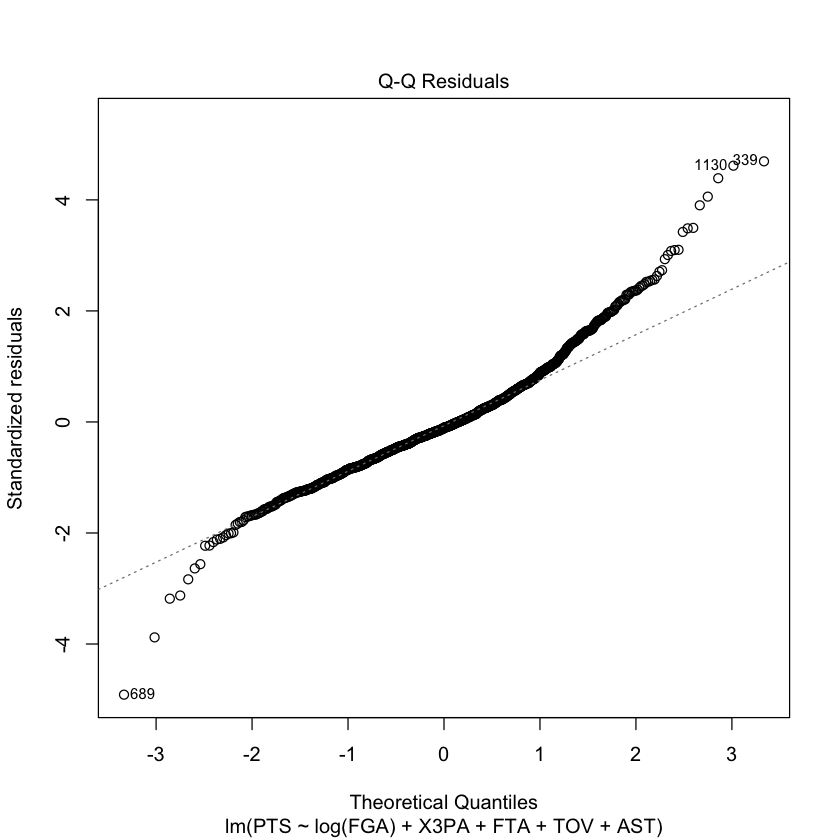

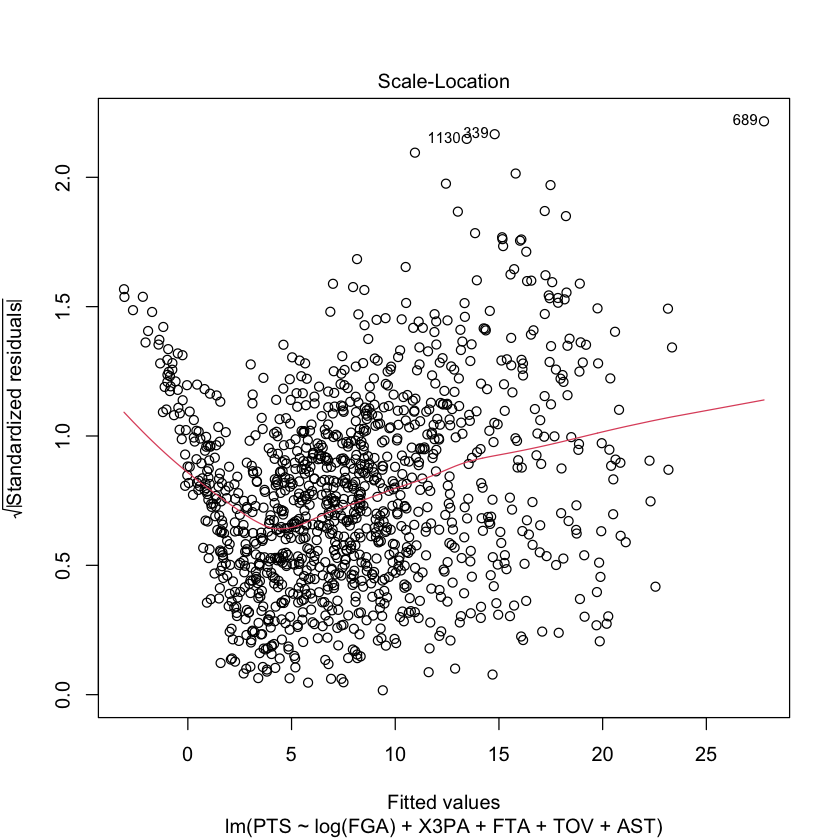

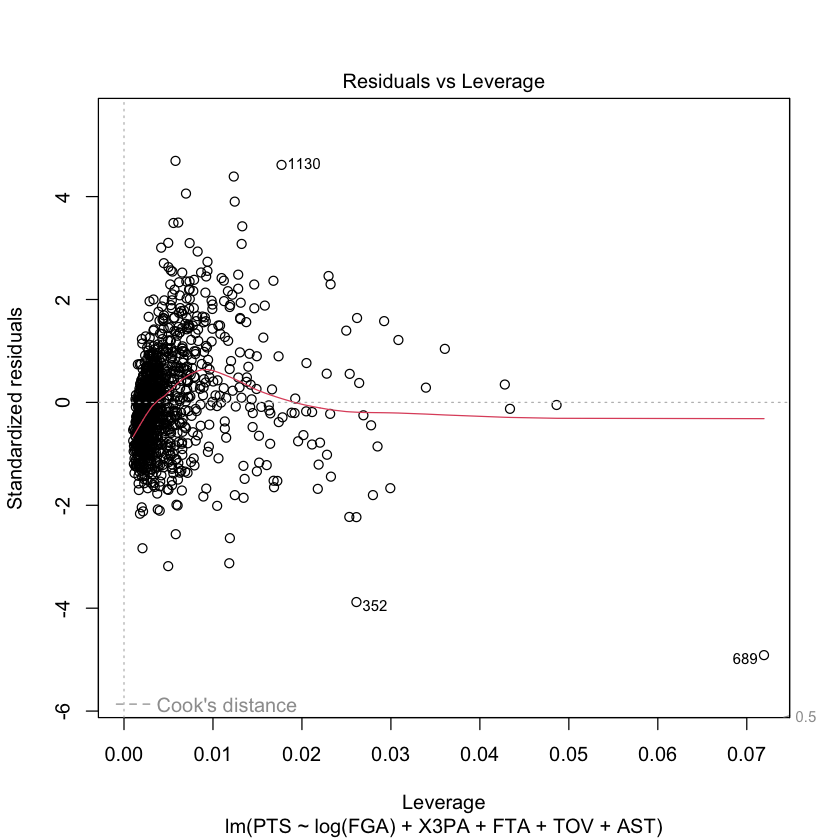

In [36]:
# mod2 = lm(PTS ~ MP + FGA + X3PA + FTA + TOV + AST, data = norm.train)
mod2 = lm(PTS ~ log(FGA) + X3PA + FTA + TOV + AST , data = norm.train)

summary(mod2)
# par(mfrow = c(2, 2))
plot(mod2)

In [37]:
vif_mod2 = vif(mod2)
print("VIF for mod2:")
print(vif_mod2)

[1] "VIF for mod2:"
log(FGA)     X3PA      FTA      TOV      AST 
4.465778 2.393162 2.562279 4.715485 2.954353 


Start:  AIC=847.24
PTS ~ log(FGA) + X3PA + FTA + TOV + AST

           Df Sum of Sq    RSS     AIC
<none>                  2389.0  847.24
- AST       1     12.12 2401.1  851.16
- TOV       1     20.16 2409.2  855.07
- X3PA      1    617.65 3006.7 1114.28
- log(FGA)  1   1239.46 3628.5 1334.22
- FTA       1   2084.17 4473.2 1579.09



Call:
lm(formula = PTS ~ log(FGA) + X3PA + FTA + TOV + AST, data = norm.train)

Residuals:
    Min      1Q  Median      3Q     Max 
-6.7797 -0.8869 -0.1500  0.6917  6.7057 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) -1.97266    0.11915 -16.556  < 2e-16 ***
log(FGA)     3.16047    0.12861  24.574  < 2e-16 ***
X3PA         0.57137    0.03294  17.347  < 2e-16 ***
FTA          1.70355    0.05346  31.866  < 2e-16 ***
TOV          0.41313    0.13181   3.134  0.00177 ** 
AST          0.10561    0.04346   2.430  0.01526 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1.433 on 1164 degrees of freedom
Multiple R-squared:  0.9272,	Adjusted R-squared:  0.9269 
F-statistic:  2967 on 5 and 1164 DF,  p-value: < 2.2e-16


,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1164,2389.024,NA,NA,NA,NA
2,1164,2389.024,0,0,NA,NA


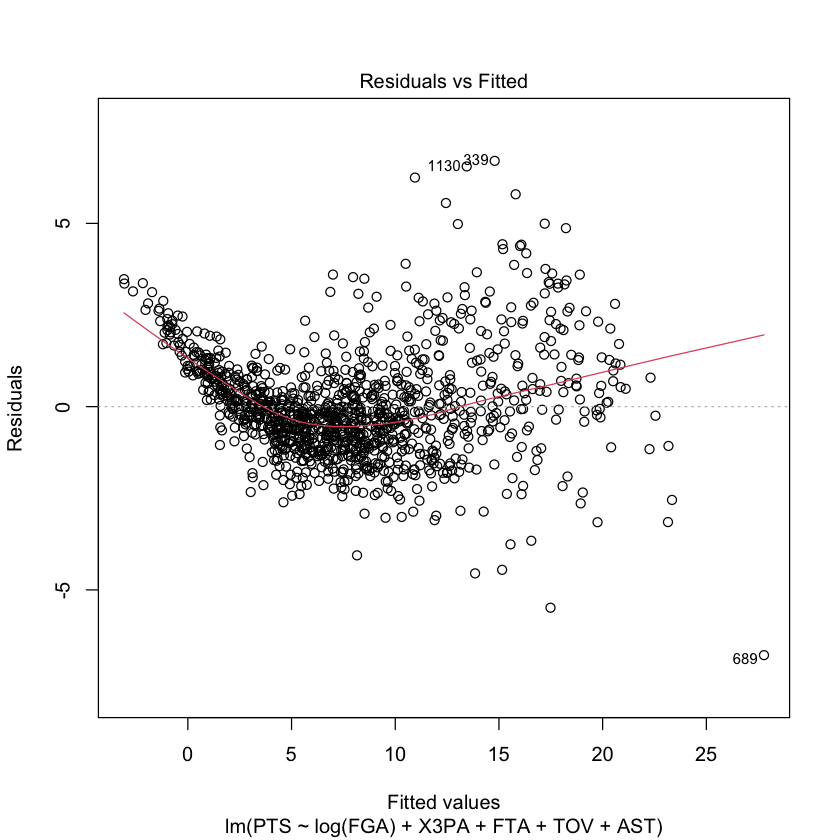

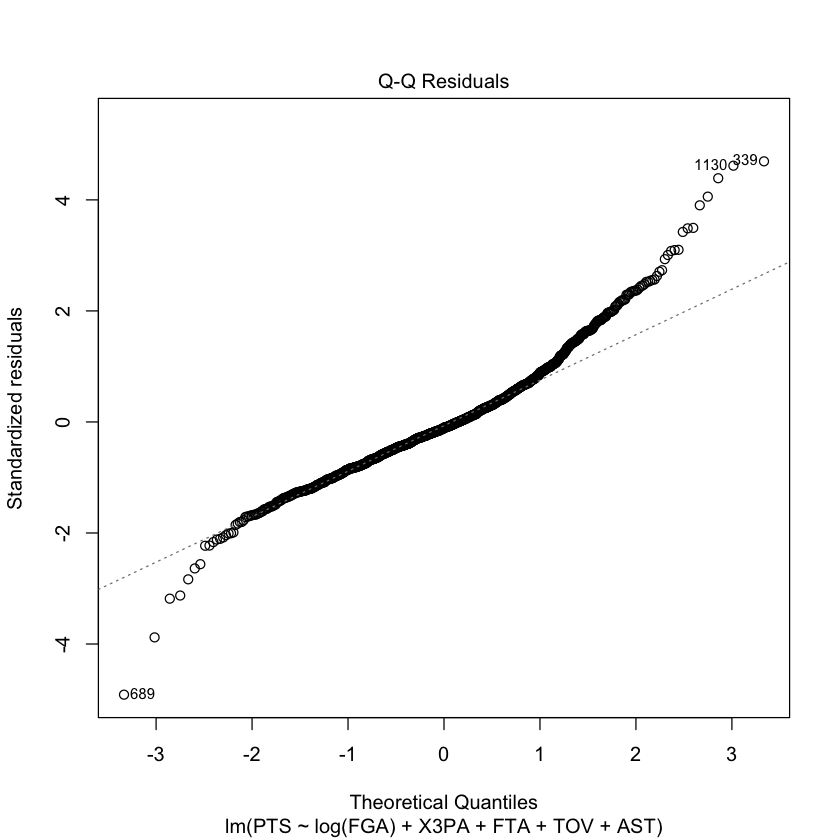

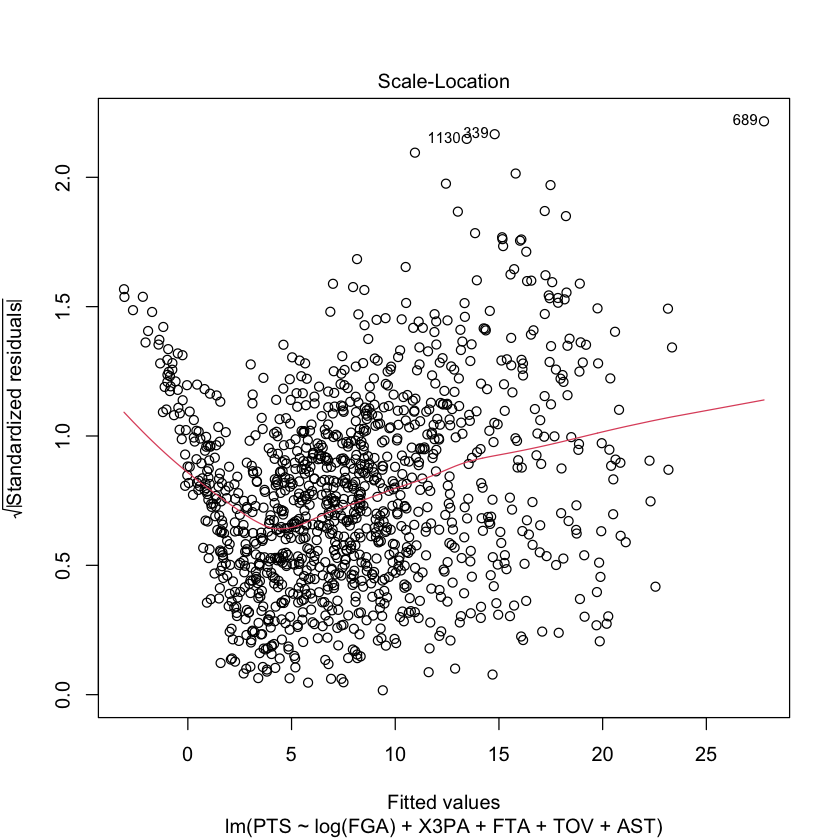

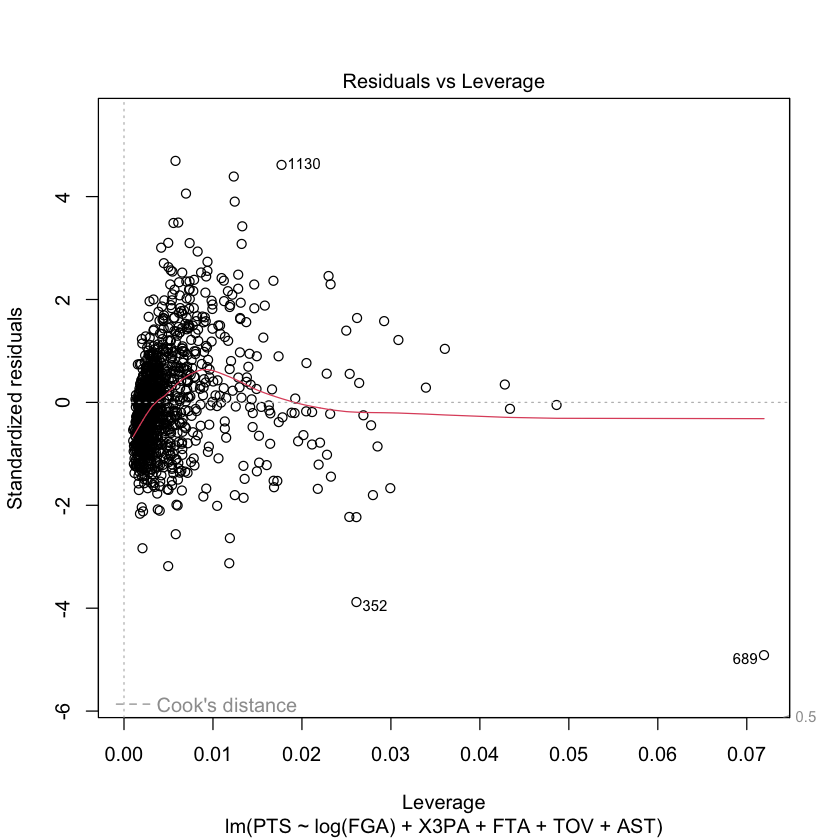

In [38]:
#Select best model using stepwise regression
library(MASS)
step_model <- step(mod2, direction = "both", trace = TRUE)

# View selected model summary
summary(step_model)

anova(step_model, mod2)
plot(step_model)
